# Spatial Generalizability Tests - GraphCast

This notebook is heavily based on the GraphCast demo at https://github.com/google-deepmind/graphcast/blob/main/graphcast_demo.ipynb

![Rotating earth: the three spatial test cases](https://raw.githubusercontent.com/marenhoever/Spatial_Generalization_Tests/main/GraphCast/images/rotating_earth_test_cases.gif)

We aim to test the **spatial generalizability of GraphCast** using the three test cases above: Rotate Longitude, Reverse Latitude, and Reverse Longitude. For a detailed explanation of the test cases, view Maren's talk at the EXCLAIM Symposium [link](https://video.ethz.ch/play/53ec5811-c0f7-416a-a37b-ed3db66b1e35/8f6a9014-3be7-451a-9b12-47c0fe3eae0b.html)

This project is work by Maren Höver, Milan Klöwer, Hannah Christensen, and Christian Schroeder De Witt

---
This colab lets you run several versions of GraphCast.
The model weights, normalization statistics, and example inputs are available on [Google Cloud Bucket](https://console.cloud.google.com/storage/browser/dm_graphcast).
A Colab runtime with TPU/GPU acceleration will substantially speed up generating predictions and computing the loss/gradients. If you're using a CPU-only runtime, you can switch using the menu "Runtime > Change runtime type".

Portions of this notebook are adapted from Google DeepMind's GraphCast demo
(<https://github.com/google-deepmind/weathernext>, formerly
`github.com/deepmind/graphcast`) -- the installation and initialization cells, the model construction/wrapping
helpers (`construct_wrapped_graphcast`, `run_forward`, `with_configs`,
`with_params`, `drop_state`), `rollout.chunked_prediction`, and the
`select`/`scale`/`plot_data` plotting helpers.
**That code has been modified for this project.** The full Apache License 2.0
text is in `LICENSE-APACHE-2.0` in this folder.

> <p><small><small>Copyright 2023 DeepMind Technologies Limited.</small></p>
> <p><small><small>Licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at <a href="http://www.apache.org/licenses/LICENSE-2.0">http://www.apache.org/licenses/LICENSE-2.0</a>.</small></small></p>
> <p><small><small>Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.</small></small></p>

## Installation and Initialization (Taken from GraphCast Demo)


In [1]:
# @title Pip install graphcast and dependencies
#%pip install --upgrade https://github.com/deepmind/graphcast/archive/master.zip

In [2]:
import sys
# graphcast is installed as a normal package in this environment, so no
# sys.path manipulation is needed.


In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# On Colab, cartopy can crash because of the default shapely build there;
# the usual workaround is
# `!pip uninstall -y shapely && pip install shapely --no-binary shapely`.
# It is not needed here -- requirements.txt pins a working shapely.


In [5]:
# @title Imports

import dataclasses
import datetime
import functools
import math
import re
from typing import Optional

import cartopy.crs as ccrs
from google.cloud import storage
from graphcast import autoregressive
from graphcast import casting
from graphcast import checkpoint
from graphcast import data_utils
from graphcast import graphcast
from graphcast import normalization
from graphcast import rollout
from graphcast import xarray_jax
from graphcast import xarray_tree
from IPython.display import HTML
import ipywidgets as widgets
import haiku as hk
import jax

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.axes import Axes

import cartopy.feature as cfeature

import numpy as np
import xarray
import netCDF4 as NC
import gc

def parse_file_parts(file_name):
  return dict(part.split("-", 1) for part in file_name.split("_"))

In [6]:
# @title Authenticate with Google Cloud Storage

gcs_client = storage.Client.create_anonymous_client()
gcs_bucket = gcs_client.get_bucket("dm_graphcast")
dir_prefix = "graphcast/"

In [7]:
# @title Plotting functions

def select(
    data: xarray.Dataset,
    variable: str,
    level: Optional[int] = None,
    max_steps: Optional[int] = None
    ) -> xarray.Dataset:
  data = data[variable]
  if "batch" in data.dims:
    data = data.isel(batch=0)
  if max_steps is not None and "time" in data.sizes and max_steps < data.sizes["time"]:
    data = data.isel(time=range(0, max_steps))
  if level is not None and "level" in data.coords:
    data = data.sel(level=level)
  return data

def scale(
    data: xarray.Dataset,
    center: Optional[float] = None,
    robust: bool = False,
    ) -> tuple[xarray.Dataset, matplotlib.colors.Normalize, str]:
  vmin = np.nanpercentile(data, (2 if robust else 0))
  vmax = np.nanpercentile(data, (98 if robust else 100))
  if center is not None:
    diff = max(vmax - center, center - vmin)
    vmin = center - diff
    vmax = center + diff
  return (data, matplotlib.colors.Normalize(vmin, vmax),
          ("RdBu_r" if center is not None else "viridis"))

def plot_data(
    data: dict[str, tuple[xarray.Dataset, any, str]],  # Assuming values are (Dataset, norm, cmap)
    fig_title: str,
    plot_size: float = 5,
    robust: bool = False,
    cols: int = 4,
    save_path: str = None  # Save path for the animation
) -> None:
    
    first_data = next(iter(data.values()))[0]
    max_steps = first_data.sizes.get("time", 1)

    for plot_data, _, _ in data.values():
        print(f"max_steps: {max_steps}, time size: {plot_data.sizes.get('time', 1)}")

    # Fix the tuple unpacking issue
    assert all(max_steps == plot_data.sizes.get("time", 1) for plot_data, _, _ in data.values())

    cols = min(cols, len(data))
    rows = math.ceil(len(data) / cols)
    
    figure = plt.figure(figsize=(plot_size * 2 * cols, plot_size * rows))
    figure.suptitle(fig_title, fontsize=16)
    figure.subplots_adjust(wspace=0, hspace=0)
    figure.tight_layout()

    ## MY ADDITION ##
    # --- Compute global min/max for the first two datasets ---
    first_two = list(data.values())[:2]  # Get first and second dataset
    all_values = np.concatenate([d[0].values.flatten() for d in first_two if "time" in d[0].dims])  # Flatten data
    vmin, vmax = np.nanmin(all_values), np.nanmax(all_values)  # Compute global min/max

    # Create a shared norm
    shared_norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)

    ## ----------- ##
    
    images = []
    for i, (title, (plot_data, norm, cmap)) in enumerate(data.items()):
        ax = figure.add_subplot(rows, cols, i+1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title)
        ## MY ADDITION ##
        im_norm = shared_norm if i < 2 else norm
        ## ----------- ##
        im = ax.imshow(
            plot_data.isel(time=0, missing_dims="ignore"), norm=im_norm, #Changed from norm to im_norm
            origin="lower", cmap=cmap)
        plt.colorbar(
            mappable=im,
            ax=ax,
            orientation="vertical",
            pad=0.02,
            aspect=16,
            shrink=0.75,
            extend=("both" if robust else "neither"))
        images.append(im)

    def update(frame):
        if "time" in first_data.dims:
            td = datetime.timedelta(microseconds=first_data["time"][frame].item() / 1000)
            figure.suptitle(f"{fig_title}, {td}", fontsize=16)
        else:
            figure.suptitle(fig_title, fontsize=16)
        for im, (plot_data, _, _) in zip(images, data.values()):
            im.set_data(plot_data.isel(time=frame, missing_dims="ignore"))

    ani = animation.FuncAnimation(
        fig=figure, func=update, frames=max_steps, interval=250
    )

    if save_path:
        ani.save(save_path, writer="ffmpeg", fps=4)  # Adjust FPS as needed
        print(f"Animation saved to {save_path}")
    else:
        return HTML(ani.to_jshtml())  # Return HTML if in a Jupyter Notebook

    plt.close(figure)

In [8]:
def animate_timeseries(da, title=None, cmap='viridis'):
    """
    Create an animation of a 2D field over time from a 3D or 4D xarray.DataArray.

    Parameters
    ----------
    da : xarray.DataArray
        Input DataArray with shape (time, lat, lon) or (batch, time, lat, lon).
    title : str, optional
        Title prefix for the animation.
    cmap : str, optional
        Colormap to use for the plot.

    Returns
    -------
    IPython.display.HTML
        The animation displayed inline in a Jupyter notebook.
    """
    # Drop batch if present
    if "batch" in da.dims:
        da = da.sel(batch=da.batch[0])

    # Check dimensions
    assert list(da.dims)[0:3] == ['time', 'lat', 'lon'], "DataArray must have shape (time, lat, lon)"

    # Set up figure
    fig, ax = plt.subplots(figsize=(8, 4))
    pcm = ax.pcolormesh(da.lon, da.lat, da[0, :, :], shading='auto', cmap=cmap)
    cbar = plt.colorbar(pcm, ax=ax)
    cbar.set_label(da.name if da.name else 'Value')

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{title or da.name} at time 0")

    # Update function
    def update(frame):
        pcm.set_array(da[frame, :, :].values.ravel())
        ax.set_title(f"{title or da.name} at time step {frame}")
        return [pcm]

    anim = FuncAnimation(fig, update, frames=da.time.size, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [9]:
# @title Load normalization data

with gcs_bucket.blob(dir_prefix+"stats/diffs_stddev_by_level.nc").open("rb") as f:
  diffs_stddev_by_level = xarray.load_dataset(f).compute()
with gcs_bucket.blob(dir_prefix+"stats/mean_by_level.nc").open("rb") as f:
  mean_by_level = xarray.load_dataset(f).compute()
with gcs_bucket.blob(dir_prefix+"stats/stddev_by_level.nc").open("rb") as f:
  stddev_by_level = xarray.load_dataset(f).compute()

In [10]:
# @title Build jitted functions, and possibly initialize random weights

def construct_wrapped_graphcast(
    model_config: graphcast.ModelConfig,
    task_config: graphcast.TaskConfig):
  """Constructs and wraps the GraphCast Predictor."""
  # Deeper one-step predictor.
  predictor = graphcast.GraphCast(model_config, task_config)

  # Modify inputs/outputs to `graphcast.GraphCast` to handle conversion to
  # from/to float32 to/from BFloat16.
  predictor = casting.Bfloat16Cast(predictor)

  # Modify inputs/outputs to `casting.Bfloat16Cast` so the casting to/from
  # BFloat16 happens after applying normalization to the inputs/targets.
  predictor = normalization.InputsAndResiduals(
      predictor,
      diffs_stddev_by_level=diffs_stddev_by_level,
      mean_by_level=mean_by_level,
      stddev_by_level=stddev_by_level)

  # Wraps everything so the one-step model can produce trajectories.
  predictor = autoregressive.Predictor(predictor, gradient_checkpointing=True)
  return predictor


@hk.transform_with_state
def run_forward(model_config, task_config, inputs, targets_template, forcings):
  predictor = construct_wrapped_graphcast(model_config, task_config)
  return predictor(inputs, targets_template=targets_template, forcings=forcings)


@hk.transform_with_state
def loss_fn(model_config, task_config, inputs, targets, forcings):
  predictor = construct_wrapped_graphcast(model_config, task_config)
  loss, diagnostics = predictor.loss(inputs, targets, forcings)
  return xarray_tree.map_structure(
      lambda x: xarray_jax.unwrap_data(x.mean(), require_jax=True),
      (loss, diagnostics))

def grads_fn(params, state, model_config, task_config, inputs, targets, forcings):
  def _aux(params, state, i, t, f):
    (loss, diagnostics), next_state = loss_fn.apply(
        params, state, jax.random.PRNGKey(0), model_config, task_config,
        i, t, f)
    return loss, (diagnostics, next_state)
  (loss, (diagnostics, next_state)), grads = jax.value_and_grad(
      _aux, has_aux=True)(params, state, inputs, targets, forcings)
  return loss, diagnostics, next_state, grads

# Jax doesn't seem to like passing configs as args through the jit. Passing it
# in via partial (instead of capture by closure) forces jax to invalidate the
# jit cache if you change configs.
def with_configs(fn):
  return functools.partial(
      fn, model_config=model_config, task_config=task_config)

# Always pass params and state, so the usage below are simpler
def with_params(fn):
  return functools.partial(fn, params=params, state=state)

# Our models aren't stateful, so the state is always empty, so just return the
# predictions. This is requiredy by our rollout code, and generally simpler.
def drop_state(fn):
  return lambda **kw: fn(**kw)[0]

## Load the Data and initialize the model (Taken from GraphCast Demo)

## Load the model params

Choose one of the two ways of getting model params:
- **random**: You'll get random predictions, but you can change the model architecture, which may run faster or fit on your device.
- **checkpoint**: You'll get sensible predictions, but are limited to the model architecture that it was trained with, which may not fit on your device. In particular generating gradients uses a lot of memory, so you'll need at least 25GB of ram (TPUv4 or A100).

Checkpoints vary across a few axes:
- The mesh size specifies the internal graph representation of the earth. Smaller meshes will run faster but will have worse outputs. The mesh size does not affect the number of parameters of the model.
- The resolution and number of pressure levels must match the data. Lower resolution and fewer levels will run a bit faster. Data resolution only affects the encoder/decoder.
- All our models predict precipitation. However, ERA5 includes precipitation, while HRES does not. Our models marked as "ERA5" take precipitation as input and expect ERA5 data as input, while model marked "ERA5-HRES" do not take precipitation as input and are specifically trained to take HRES-fc0 as input (see the data section below).

We provide three pre-trained models.
1. `GraphCast`, the high-resolution model used in the GraphCast paper (0.25 degree resolution, 37 pressure levels), trained on ERA5 data from 1979 to 2017,

2. `GraphCast_small`, a smaller, low-resolution version of GraphCast (1 degree resolution, 13 pressure levels, and a smaller mesh), trained on ERA5 data from 1979 to 2015, useful to run a model with lower memory and compute constraints,

3. `GraphCast_operational`, a high-resolution model (0.25 degree resolution, 13 pressure levels) pre-trained on ERA5 data from 1979 to 2017 and fine-tuned on HRES data from 2016 to 2021. This model can be initialized from HRES data (does not require precipitation inputs).


----

### <span style="color: red">Here we choose Checkpoint - GraphCast_small!</span>

### Choose the model

The model choice is set explicitly below -- **Checkpoint > GraphCast_small** --
so the notebook runs top to bottom without interactive widgets. Edit the
assignment if you want to use a different checkpoint.

In [11]:
PARAMS_FILE = "GraphCast_small - ERA5 1979-2015 - resolution 1.0 - pressure levels 13 - mesh 2to5 - precipitation input and output.npz"

with gcs_bucket.blob(f"{dir_prefix}params/{PARAMS_FILE}").open("rb") as f:
  ckpt = checkpoint.load(f, graphcast.CheckPoint)
params = ckpt.params
state = {}

model_config = ckpt.model_config
task_config = ckpt.task_config
print("Model description:\n", ckpt.description, "\n")
print("Model license:\n", ckpt.license, "\n")
model_config


Model description:
 
Low resolution version of the GraphCast model (1deg, smaller mesh), with 37
pressure levels. This model is trained on ERA5 data from 1979 to 2015, and can
be causally evaluated on 2016 and later years. This model takes as inputs
`total_precipitation_6hr`. This model has much lower memory requirements.
 

Model license:
 
The model weights are licensed under the Creative Commons
Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0). You
may obtain a copy of the License at:
https://creativecommons.org/licenses/by-nc-sa/4.0/.
The weights were trained on ERA5 data, see README for attribution statement.
 



ModelConfig(resolution=1.0, mesh_size=5, latent_size=512, gnn_msg_steps=16, hidden_layers=1, radius_query_fraction_edge_length=0.6, mesh2grid_edge_normalization_factor=0.6180338738074472)

## Load the example data (Taken from GraphCast Demo)

Several example datasets are available, varying across a few axes:
- **Source**: fake, era5, hres
- **Resolution**: 0.25deg, 1deg, 6deg
- **Levels**: 13, 37
- **Steps**: How many timesteps are included

Not all combinations are available.
- Higher resolution is only available for fewer steps due to the memory requirements of loading them.
- HRES is only available in 0.25 deg, with 13 pressure levels.

The data resolution must match the model that is loaded.

Some transformations were done from the base datasets:
- We accumulated precipitation over 6 hours instead of the default 1 hour.
- For HRES data, each time step corresponds to the HRES forecast at leadtime 0, essentially providing an "initialisation" from HRES. See HRES-fc0 in the GraphCast paper for further description. Note that a 6h accumulation of precipitation is not available from HRES, so our model taking HRES inputs does not depend on precipitation. However, because our models predict precipitation, we include the ERA5 precipitation in the example data so it can serve as an illustrative example of ground truth.
- We include ERA5 `toa_incident_solar_radiation` in the data. Our model uses the radiation at -6h, 0h and +6h as a forcing term for each 1-step prediction. If the radiation is missing from the data (e.g. in an operational setting), it will be computed using a custom implementation that produces values similar to those in ERA5.

----

### <span style="color: red">For this Demo let's choose source: era5, date 2022-01-01, res:1.0, levels 13, <u>steps:40</u></span> 

### Get and load the example dataset

Same as above -- hardcoding the documented choice ("source: era5, date
2022-01-01, res:1.0, levels 13, steps:40") instead of an interactive
dropdown. `data_valid_for_model` (the original's own validity check) is
kept and asserted against, so this still fails loudly if the hardcoded
file were ever inconsistent with the chosen model.


In [12]:
def data_valid_for_model(
    file_name: str, model_config: graphcast.ModelConfig, task_config: graphcast.TaskConfig):
  file_parts = parse_file_parts(file_name.removesuffix(".nc"))
  return (
      model_config.resolution in (0, float(file_parts["res"])) and
      len(task_config.pressure_levels) == int(file_parts["levels"]) and
      (
          ("total_precipitation_6hr" in task_config.input_variables and
           file_parts["source"] in ("era5", "fake")) or
          ("total_precipitation_6hr" not in task_config.input_variables and
           file_parts["source"] in ("hres", "fake"))
      )
  )

DATASET_FILE = "source-era5_date-2022-01-01_res-1.0_levels-13_steps-40.nc"
assert data_valid_for_model(DATASET_FILE, model_config, task_config)

with gcs_bucket.blob(f"{dir_prefix}dataset/{DATASET_FILE}").open("rb") as f:
  example_batch = xarray.load_dataset(f).compute()

assert example_batch.dims["time"] >= 3  # 2 for input, >=1 for targets

print(", ".join([f"{k}: {v}" for k, v in parse_file_parts(DATASET_FILE.removesuffix(".nc")).items()]))


source: era5, date: 2022-01-01, res: 1.0, levels: 13, steps: 40


In [13]:
example_batch

<xarray.Dataset> Size: 920MB
Dimensions:                       (lat: 181, lon: 360, batch: 1, time: 42,
                                   level: 13)
Coordinates:
  * lat                           (lat) float32 724B -90.0 -89.0 ... 89.0 90.0
  * lon                           (lon) float32 1kB 0.0 1.0 2.0 ... 358.0 359.0
  * time                          (time) timedelta64[ns] 336B 0 days 00:00:00...
    datetime                      (batch, time) datetime64[ns] 336B 2022-01-0...
  * level                         (level) int32 52B 50 100 150 ... 850 925 1000
Dimensions without coordinates: batch
Data variables: (12/14)
    geopotential_at_surface       (lat, lon) float32 261kB 2.735e+04 ... -0.0...
    land_sea_mask                 (lat, lon) float32 261kB 1.0 1.0 ... 0.0 0.0
    2m_temperature                (batch, time, lat, lon) float32 11MB 250.7 ...
    mean_sea_level_pressure       (batch, time, lat, lon) float32 11MB 9.931e...
    10m_v_component_of_wind       (batch, time, lat, lon) float32 11MB -0.439...
    10m_u_component_of_wind       (batch, time, lat, lon) float32 11MB 1.309 ...
    ...                            ...
    temperature                   (batch, time, level, lat, lon) float32 142MB ...
    geopotential                  (batch, time, level, lat, lon) float32 142MB ...
    u_component_of_wind           (batch, time, level, lat, lon) float32 142MB ...
    v_component_of_wind           (batch, time, level, lat, lon) float32 142MB ...
    vertical_velocity             (batch, time, level, lat, lon) float32 142MB ...
    specific_humidity             (batch, time, level, lat, lon) float32 142MB ...

## Reversing/ Rotating the Data 

The following function is used to apply our test cases to the GraphCast input data

In [14]:
def flip(data: xarray.Dataset, rotation: str) -> xarray.Dataset:
    """
    Applies one of the three test cases: rotate longitude (rotlon), reverse latitude (revlat), and reverse longitude (revlon). 
    For the rotlon & revlat test cases the datetime is shifted to account for changes in incoming solar radiation.
    For the revlat & revlon test cases changes are applied to the v/ u wind vectors respectively to keep simulations physically consistent.

    Parameters
    ----------
    data : xarray.Dataset
        Input data with ERA5-like variables and coordinates.
    rotation : str
        One of: 'revlat', 'revlon', 'rotlon'

    Returns
    -------
    xarray.Dataset
        Flipped dataset
    """
    new_data = data.copy()

    def _flip_lat(ds):
        # Reversing the latitude and then asserting that the values of the
        # lat coordinates are the same as before.
        flipped = ds.sel(lat=slice(None, None, -1))
        flipped = flipped.assign_coords(lat=flipped.lat.values[::-1])
        return flipped

    def _flip_lon(ds):
        # Reversing the longitude and then asserting that the values of the
        # lon coordinates are the same as before.
        flipped = ds.sel(lon=slice(None, None, -1))
        flipped = flipped.assign_coords(lon=flipped.lon.values[::-1])
        return flipped

    def _shift_lon(ds):
        # Shifting the lon coordinates by 180deg
        n = ds.sizes['lon']
        return ds.roll(lon=n // 2, roll_coords=False)

    if rotation == "revlat":
        new_data = _flip_lat(new_data)

        for key in new_data.data_vars:
            # Changing the sign of the v-component of the wind
            if "v_component_of_wind" in key and "10m" not in key:
                new_data[key] = -new_data[key]
            if "10m_v_component_of_wind" in key:
                new_data[key] = -new_data[key]

        if "datetime" in new_data.coords:
            # Adding 183 days to account for change in seasonality
            og_datetimes = new_data.copy().datetime
            shifted_datetimes = og_datetimes + np.timedelta64(183, "D")
            new_data.datetime.values = shifted_datetimes.values

    elif rotation == "revlon":
        new_data = _flip_lon(new_data)

        for key in new_data.data_vars:
            # Changing the sign of the u-component of the wind
            if "u_component_of_wind" in key and "10m" not in key:
                new_data[key] = -new_data[key]
            if "10m_u_component_of_wind" in key:
                new_data[key] = -new_data[key]

    elif rotation == "rotlon":
        new_data = _shift_lon(new_data)

        if "datetime" in new_data.coords:
            # Subtracting 12h to account for change in incoming solar radiation
            og_datetimes = new_data.copy().datetime
            shifted_datetimes = og_datetimes - np.timedelta64(12, "h")
            new_data.datetime.values = shifted_datetimes.values

    else:
        print("This rotation is not defined, please choose rotlon, revlat, or revlon")

    return new_data


def flip_back(data: xarray.Dataset, rotation: str) -> xarray.Dataset:
    """
    Reverses the changes made for the test cases: rotate longitude (rotlon), reverse latitude (revlat), and reverse longitude (revlon). 
    The predictions do not have explicit datetime information, i.e. these changes can not be reversed.
    For the revlat & revlon test cases changes are applied to the v/ u wind vectors respectively to keep simulations physically consistent.

    Parameters
    ----------
    data : xarray.Dataset
        Input data with ERA5-like variables and coordinates.
    rotation : str
        One of: 'revlat', 'revlon', 'rotlon'

    Returns
    -------
    xarray.Dataset
        Flipped dataset
    """
    new_data = data.copy()

    def _flip_lat_back(ds):
        flipped = ds.sel(lat=slice(None, None, -1))
        flipped = flipped.assign_coords(lat=flipped.lat.values[::-1])
        return flipped

    def _flip_lon_back(ds):
        flipped = ds.sel(lon=slice(None, None, -1))
        flipped = flipped.assign_coords(lon=flipped.lon.values[::-1])
        return flipped

    def _shift_lon_back(ds):
        n = ds.sizes['lon']
        return ds.roll(lon=- n // 2, roll_coords=False)

    if rotation == "revlat":
        new_data = _flip_lat_back(new_data)

        for key in new_data.data_vars:
            if "v_component_of_wind" in key and "10m" not in key:
                new_data[key] = -new_data[key]
            if "10m_v_component_of_wind" in key:
                new_data[key] = -new_data[key]

    elif rotation == "revlon":
        new_data = _flip_lon_back(new_data)

        for key in new_data.data_vars:
            if "u_component_of_wind" in key and "10m" not in key:
                new_data[key] = -new_data[key]
            if "10m_u_component_of_wind" in key:
                new_data[key] = -new_data[key]

    elif rotation == "rotlon":
        new_data = _shift_lon_back(new_data)

    else:
        print("This rotation is not defined, please choose rotlon, revlat, or revlon")

    return new_data

Defining the initial conditions for each of our test cases using the flip() function above.

In [15]:
normal_ini = example_batch.copy()
rotlon_ini = flip(example_batch.copy(), 'rotlon')
revlat_ini = flip(example_batch.copy(), 'revlat')
revlon_ini = flip(example_batch.copy(),'revlon')

In [16]:
ini_data = [normal_ini, rotlon_ini, revlat_ini, revlon_ini]

In [17]:
ini_labels = ['normal', 'rotlon', 'revlat', 'revlon']

As an example, plotting the 2mT input data for each test case

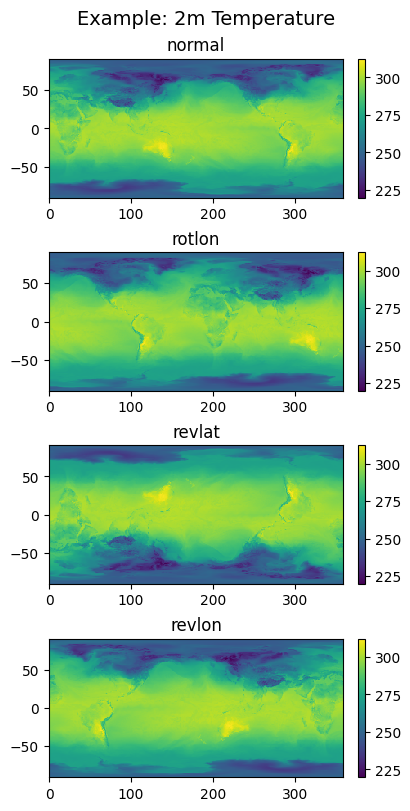

In [18]:
fig, axes = plt.subplots(nrows=4, figsize=(4, 8), constrained_layout=True)
for ax, data, label in zip(axes, ini_data, ini_labels):
    temp = data.sel(batch=data.batch[0])['2m_temperature'][0, :, :]
    pcm = ax.pcolormesh(data.lon, data.lat, temp)
    ax.set_title(label)
    fig.colorbar(pcm, ax=ax, orientation='vertical')
fig.suptitle('Example: 2m Temperature', fontsize=14)
plt.show()

However, this applies to all other boundary & initial conditions as well

In [19]:
n_datasets = len(ini_data)
n_vars = len(ini_data[0].data_vars)
var_names = list(ini_data[0].data_vars)

fig, axes = plt.subplots(
    nrows=n_datasets,
    ncols=n_vars,
    figsize=(4 * n_vars, 3 * n_datasets),
    constrained_layout=True
)

for row_idx, (row_axes, data, label) in enumerate(zip(axes, ini_data, ini_labels)):
    for col_idx, (ax, var_name) in enumerate(zip(row_axes, var_names)):
        da = data[var_name]
        try:
            if {'batch', 'time', 'level'}.issubset(da.dims):
                slice2d = da.sel(batch=da.batch[0], time=da.time[0], level=da.level[0])
            elif {'batch', 'time'}.issubset(da.dims):
                slice2d = da.sel(batch=da.batch[0], time=da.time[0])
            elif {'lat', 'lon'}.issubset(da.dims):
                slice2d = da
            else:
                raise ValueError("Unhandled shape")

            pcm = ax.pcolormesh(data.lon, data.lat, slice2d, shading="auto")
            ax.set_xticks([])
            ax.set_yticks([])
            if row_idx == 0:
                ax.set_title(var_name, fontsize=18)
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=18)
            fig.colorbar(pcm, ax=ax, orientation="vertical")
        except Exception as e:
            ax.set_title(f"{var_name} (skip)")
            ax.revlon("off")
plt.show()

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

Importantly, we are accounting for incoming solar radiation & direction of the wind vectors to stay as physically consistent as possible when applying our test cases. See details below:

#### Incoming Solar Radiation

We find that even though we are changing the TOA incident solar radiation variable, GraphCast has learned the daily cycle via time-of-day. To account for this, we subtract 12h from the datetime information of the input data for the rotate longitude case (since rotating in longitude by 180$^\circ$ corresponds to moving forward in time by 12h). For the reverse latitude case, we add 183 days to account for seasonality, without changing the time-of-day. Unfortunately, we do not see a straightforward way to account for this in the reverse longitude case.

<img src="https://raw.githubusercontent.com/marenhoever/Spatial_Generalization_Tests/main/GraphCast/images/test_case_start_datetimes.png" width="600"/>

Example: simulation starting datetime for each test case

In [20]:
print('Normal test case: ' + str(normal_ini.datetime.values[0][0]))
print('RotLon test case: ' + str(rotlon_ini.datetime.values[0][0]))
print('RevLat test case: ' + str(revlat_ini.datetime.values[0][0]))
print('RevLon test case: ' + str(revlon_ini.datetime.values[0][0]))

Normal test case: 2022-01-01T00:00:00.000000000
RotLon test case: 2021-12-31T12:00:00.000000000
RevLat test case: 2022-07-03T00:00:00.000000000
RevLon test case: 2022-01-01T00:00:00.000000000


### Wind Vectors/ Coriolis

Additionally, we account for dynamical factors as illustrated in this graphic:

<img src="https://raw.githubusercontent.com/marenhoever/Spatial_Generalization_Tests/main/GraphCast/images/test_case_wind_components.png" width="600">

That is, we change the sign of the v-component of the wind in the revlat test case, and the sign of the u-component in the revlon test case. See plots below:

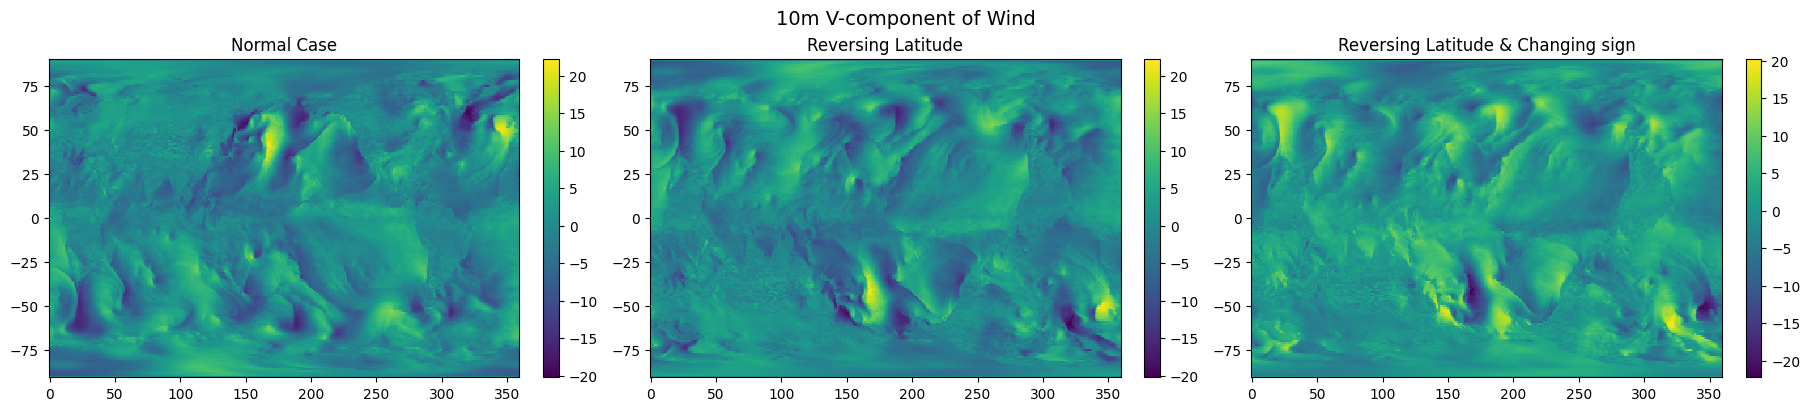

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

axes[0].set_title("Normal Case")
pcm = axes[0].pcolormesh(
    normal_ini.lon,
    normal_ini.lat,
    normal_ini.sel(batch=normal_ini.batch[0])["10m_v_component_of_wind"][0, :, :],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[0])

axes[1].set_title("Reversing Latitude")
pcm = axes[1].pcolormesh(
    normal_ini.lon,
    normal_ini.lat,
    normal_ini.sel(batch=normal_ini.batch[0])["10m_v_component_of_wind"][0, :, :][::-1,:],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[1])

axes[2].set_title("Reversing Latitude & Changing sign")
pcm = axes[2].pcolormesh(
    revlat_ini.lon,
    revlat_ini.lat,
    revlat_ini.sel(batch=revlat_ini.batch[0])["10m_v_component_of_wind"][0, :, :],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[2])

plt.suptitle("10m V-component of Wind", fontsize=14)
plt.show()

-> We are doing the latter, i.e. reversing latitude & changing the sign of the v-component of the wind in the revlat case.

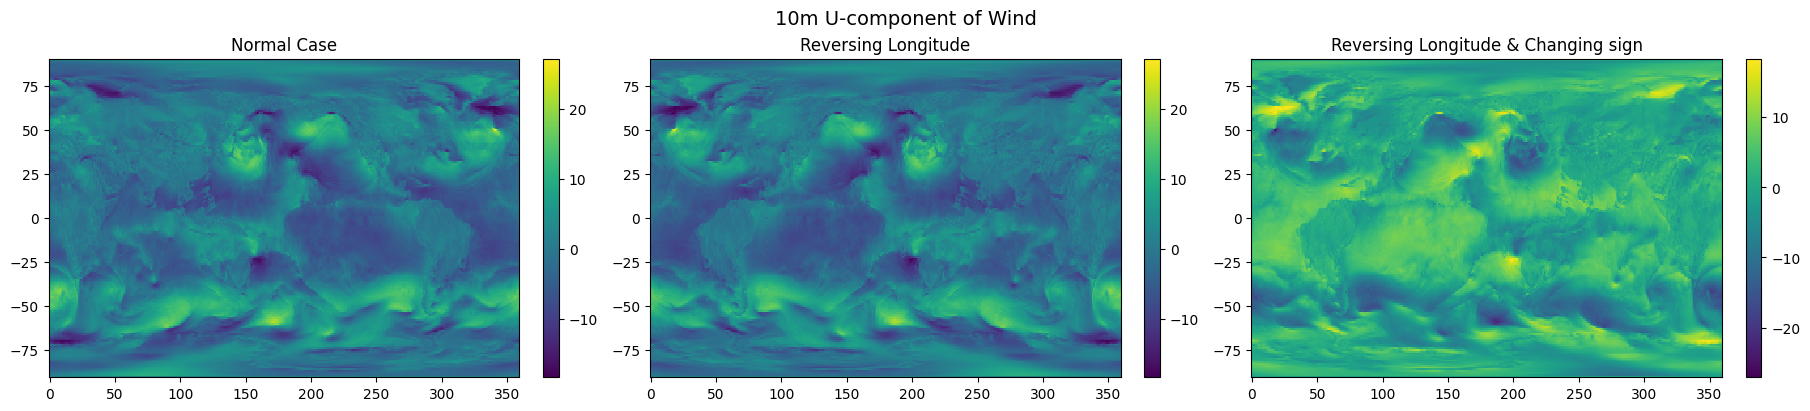

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

axes[0].set_title("Normal Case")
pcm = axes[0].pcolormesh(
    normal_ini.lon,
    normal_ini.lat,
    normal_ini.sel(batch=normal_ini.batch[0])["10m_u_component_of_wind"][0, :, :],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[0])

axes[1].set_title("Reversing Longitude")
pcm = axes[1].pcolormesh(
    normal_ini.lon,
    normal_ini.lat,
    normal_ini.sel(batch=normal_ini.batch[0])["10m_u_component_of_wind"][0, :, :][:,::-1],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[1])

axes[2].set_title("Reversing Longitude & Changing sign")
pcm = axes[2].pcolormesh(
    revlon_ini.lon,
    revlon_ini.lat,
    revlon_ini.sel(batch=revlon_ini.batch[0])["10m_u_component_of_wind"][0, :, :],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[2])

plt.suptitle("10m U-component of Wind", fontsize=14)
plt.show()

-> We are doing the latter, i.e. reversing longitude & changing the sign of the u-component of the wind in the revlon case.

This is true at all levels, not just 10m

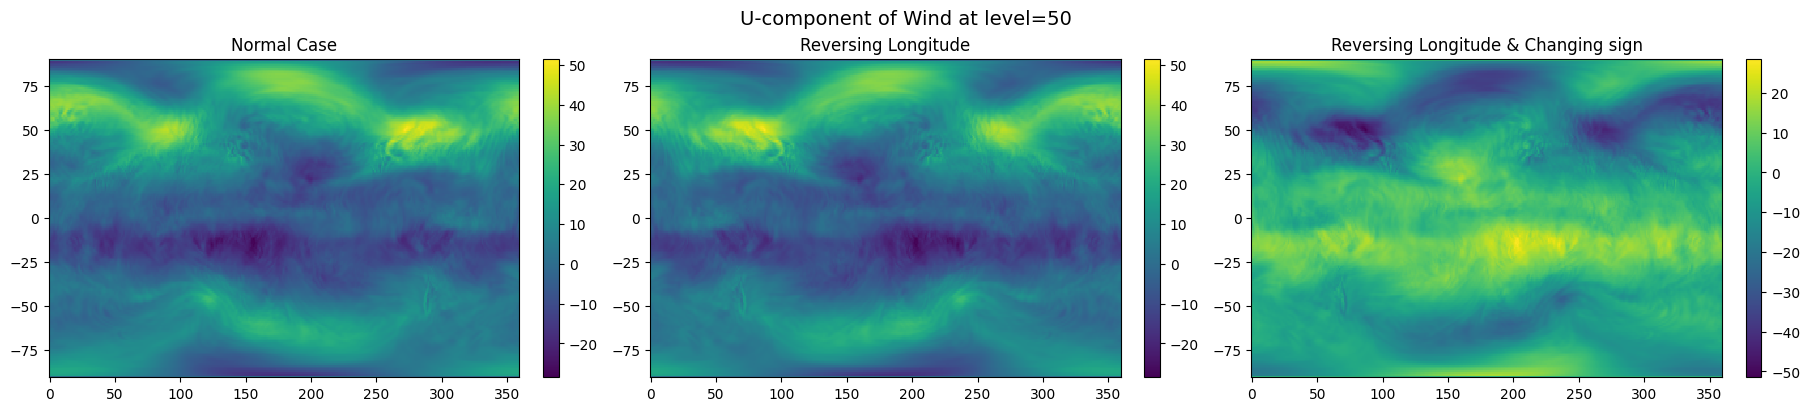

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)

axes[0].set_title("Normal Case")
pcm = axes[0].pcolormesh(
    normal_ini.lon,
    normal_ini.lat,
    normal_ini.sel(batch=normal_ini.batch[0])["u_component_of_wind"][0, 0, :, :],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[0])

axes[1].set_title("Reversing Longitude")
pcm = axes[1].pcolormesh(
    normal_ini.lon,
    normal_ini.lat,
    normal_ini.sel(batch=normal_ini.batch[0])["u_component_of_wind"][0,0, :, :][:,::-1],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[1])

axes[2].set_title("Reversing Longitude & Changing sign")
pcm = axes[2].pcolormesh(
    revlon_ini.lon,
    revlon_ini.lat,
    revlon_ini.sel(batch=revlon_ini.batch[0])["u_component_of_wind"][0,0, :, :],
    shading='auto'
)
fig.colorbar(pcm, ax=axes[2])

plt.suptitle("U-component of Wind at level=50", fontsize=14)
plt.show()

### Running the model

In [24]:
def run_model(input_data):
    # Hard-coding this since we are always running 10-day forecasts
    train_steps = 1  
    eval_steps = 40  

    eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
        input_data, target_lead_times=slice("6h", f"{eval_steps*6}h"),
        **dataclasses.asdict(task_config))

    
    init_jitted = jax.jit(with_configs(run_forward.init))
    
    loss_fn_jitted = drop_state(with_params(jax.jit(with_configs(loss_fn.apply))))
    grads_fn_jitted = with_params(jax.jit(with_configs(grads_fn)))
    run_forward_jitted = drop_state(with_params(jax.jit(with_configs(
        run_forward.apply))))
    
    predictions = rollout.chunked_prediction(
            run_forward_jitted,
            rng=jax.random.PRNGKey(0),
            inputs=eval_inputs,
            targets_template=eval_targets * np.nan,
            forcings=eval_forcings)

    assert model_config.resolution in (0, 360. / eval_inputs.sizes["lon"]), (
          "Model resolution doesn't match the data resolution. You likely want to "
          "re-filter the dataset list, and download the correct data.")

    # Saving only the surface variables for further use
    variables_to_drop = ['temperature', 'geopotential', 'u_component_of_wind', 'v_component_of_wind']
    predictions = predictions.drop_vars(variables_to_drop)
    surface_vars = predictions.sel(level=1000, method="nearest")
    return surface_vars

In [25]:
normal_pred = run_model(normal_ini.copy())
rotlon_pred = run_model(rotlon_ini.copy())
revlat_pred = run_model(revlat_ini.copy())
revlon_pred = run_model(revlon_ini.copy())

In [26]:
animate_timeseries(normal_pred['2m_temperature'], title='Normal Test Case', cmap='viridis')

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

In [27]:
animate_timeseries(rotlon_pred['2m_temperature'], title='RotLon Test Case', cmap='viridis')

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

In [28]:
animate_timeseries(revlat_pred['2m_temperature'], title='RevLat Test Case', cmap='viridis')

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

In [29]:
animate_timeseries(revlon_pred['2m_temperature'], title='RevLon Test Case', cmap='viridis')

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

### Flipping Back

In [30]:
rotlon_pred_flipped_back = flip_back(rotlon_pred.copy(), 'rotlon')
revlat_pred_flipped_back = flip_back(revlat_pred.copy(), 'revlat')
revlon_pred_flipped_back = flip_back(revlon_pred.copy(), 'revlon')

In [31]:
animate_timeseries(rotlon_pred_flipped_back['2m_temperature'], title='RotLon Test Case - Flipped back', cmap='viridis')

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

In [32]:
animate_timeseries(revlat_pred_flipped_back['2m_temperature'], title='RevLat Test Case - Flipped back', cmap='viridis')

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

In [33]:
animate_timeseries(revlon_pred_flipped_back['2m_temperature'], title='RevLon Test Case - Flipped back', cmap='viridis')

[animation output stripped for repo size -- re-run this cell to view; execution_count confirms it ran with zero errors]

The reverse longitude case is certainly the hardest test to pass, and we expect the error to be comparatively high, since we can not adjust for the changes in incoming solar radiation via the datetime information, as the changes would be small around the prime meridian and larger at further away longitudes. Additionally, we can see that despite changing the sign of the u-component of the wind vector, the wind is flowing in the wrong direction. If we do not make this change to the u-vector of the wind we get an even higher RMSE.

### Calculating Error

We are calculating the forecast error and the generalization errors for each test case for 2mT

In [34]:
# Getting the eval_targets to calculate forecast error
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
        normal_ini, target_lead_times=slice("6h", f"{40*6}h"),
        **dataclasses.asdict(task_config))

In [35]:
# Calculating the general forecast error, i.e. normal predictions compared to eval targets (ERA5)
forecast_error = normal_pred['2m_temperature'].squeeze().values - eval_targets['2m_temperature'].squeeze().values
# Calculating the generalization errors, i.e. normal predictions compared to flipped back test case predictions
rotlon_error = normal_pred['2m_temperature'].squeeze().values - rotlon_pred_flipped_back['2m_temperature'].squeeze().values
revlat_error = normal_pred['2m_temperature'].squeeze().values - revlat_pred_flipped_back['2m_temperature'].squeeze().values
revlon_error = normal_pred['2m_temperature'].squeeze().values - revlon_pred_flipped_back['2m_temperature'].squeeze().values

In [36]:
lat_weights = np.cos(np.deg2rad(normal_ini.lat))
lat_weights = lat_weights.values.reshape(1, len(lat_weights.values), 1)

In [37]:
# Calculating the lat-weighted squared error
forecast_se = (forecast_error ** 2) * lat_weights
rotlon_se = (rotlon_error ** 2) * lat_weights
revlat_se = (revlat_error ** 2) * lat_weights
revlon_se = (revlon_error  ** 2) * lat_weights

### Plotting

In [38]:
forecast_se.shape

(40, 181, 360)

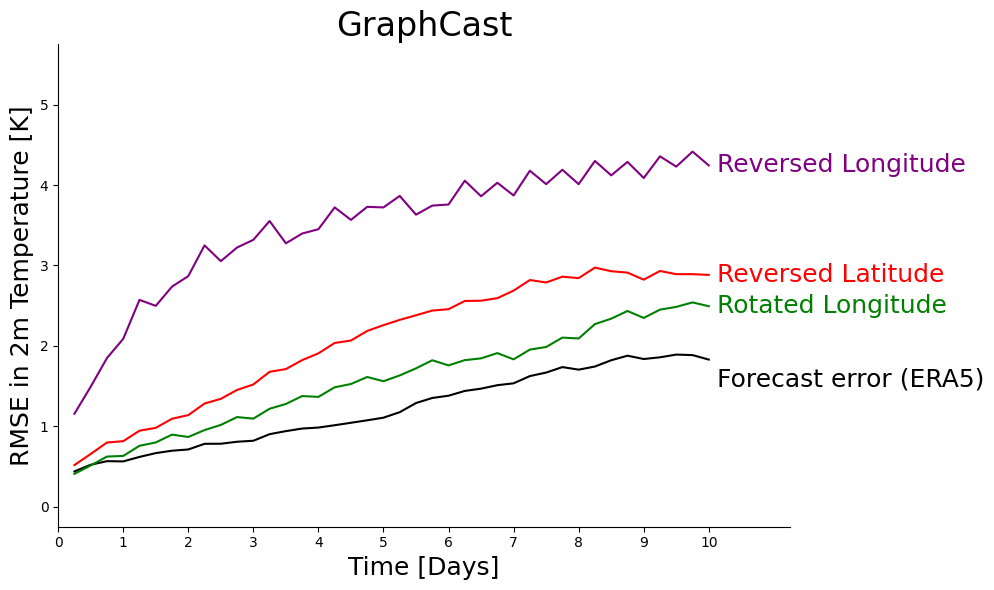

In [39]:
arrays = [
    # Calculating the RMSE
    np.sqrt(np.mean(forecast_se, axis=(1,2))),
    np.sqrt(np.mean(rotlon_se, axis=(1,2))),
    np.sqrt(np.mean(revlat_se, axis=(1,2))),
    np.sqrt(np.mean(revlon_se, axis=(1,2)))
]

colors = ['black', 'green', 'red', 'purple']
labels = ['Forecast error (ERA5)', 'Rotated Longitude', 'Reversed Latitude', 'Reversed Longitude']


plt.figure(figsize=(10, 6))
x_values = np.arange(40) + 1


for data, color, label in zip(arrays, colors, labels):
    linestyle = '--' if color == 'black' else '-' 
    plt.plot(x_values, data, color=color)
    #mean_line = data.mean(axis=0)
    #plt.plot(x_values, mean_line, color=color, linewidth=2, linestyle=linestyle)

    # Adjust vertical position of black label to avoid overlap
    y_offset = -0.25 if label == 'Forecast error (ERA5)' else 0

    plt.text(
        x_values[-1] + 0.5,
        data[-1] + y_offset,
        label,
        color=color,
        va='center',
        fontsize=18,
        bbox=dict(facecolor='white', edgecolor='none')
    )

# Axis formatting
plt.xticks(np.arange(0, 41, 4), np.arange(0, 11, 1))
plt.xlabel('Time [Days]', fontsize=18)
plt.ylabel('RMSE in 2m Temperature [K]', fontsize=18)
plt.title('GraphCast', fontsize=24)

# Extend x-axis range to show origin and prevent clipping of labels
plt.xlim(0, x_values[-1] + 5)
plt.ylim(-0.25, 5.75)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.tick_params(left=True, bottom=True, right=False, top=False)

plt.tight_layout()
plt.show()

### When running for each day of the year (initializing at 6pm the previous day, rather than midnight as in the example above)

<img src="https://raw.githubusercontent.com/marenhoever/Spatial_Generalization_Tests/main/GraphCast/images/graphcast_vs_speedy_rmse.jpeg" width="800"/>



In this case, the "Rounding Error" are the results we get when applying the test cases in a GCM (SpeedyWeather), i.e. in a physics-based general circulation model the test cases only result in a minimal rounding error. Each of the faint lines corresponds to a 10-day forecast initialized on a day of the year 2022, with the bold lines indicating the mean.

We say that the model generalizes spatially if the generalization error is much smaller than the forecast error. Hence, at this point GraphCast would not pass these tests.